<a href="https://colab.research.google.com/github/boriskbr27-web/phoenix-autocall-pricer/blob/main/phoenix_autocall_pricer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phoenix Autocall Pricer — Monte Carlo + Greeks + Surface de Volatilité

**Auteur :** Jean-Marie Boris KABORÉ  
**MBA Trading & Finance de Marché** — ESLSCA Business School Paris (Promo 2026)  
**Middle/Back Office Investment Officer** — Gresham Banque Privée (Groupe APICIL)

---

## Architecture du notebook

| Section | Contenu |
|---|---|
| 1 | Rappel théorique — GBM & mesure risque-neutre |
| 2 | Paramétrage du produit |
| 3 | Moteur Monte Carlo |
| 4 | Calcul des Greeks (différences finies) |
| 5 | Surface de volatilité implicite |
| 6 | Analyse du profil risque/rendement |
| 7 | Sensibilité des Greeks aux paramètres |


## 1. Imports & configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import ticker
from scipy.stats import norm
from scipy.interpolate import RectBivariateSpline
import warnings
warnings.filterwarnings("ignore")

# Style global
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f9f9f9",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "DejaVu Sans",
    "font.size":        11,
})
PURPLE = "#534AB7"
TEAL   = "#1D9E75"
CORAL  = "#D85A30"
AMBER  = "#BA7517"

print("Librairies chargées avec succès ✓")


Librairies chargées avec succès ✓


## 2. Rappel théorique

### Mouvement Brownien Géométrique (GBM)

Sous la mesure risque-neutre $\mathbb{Q}$, chaque sous-jacent $S_i$ suit :

$$dS_i = r \, S_i \, dt + \sigma_i \, S_i \, dW_i^\mathbb{Q}$$

**Discrétisation d'Euler-Maruyama :**

$$S_{t+\Delta t} = S_t \cdot \exp\!\left[\left(r - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t}\, Z\right], \quad Z \sim \mathcal{N}(0,1)$$

### Structure Phoenix Autocall

À chaque date d'observation $t_k$ ($k = 1, \ldots, n$) :

| Condition | Événement |
|---|---|
| $\text{Basket}_{t_k} \geq B_{\text{rappel}}$ | Rappel anticipé → remboursement $N \times (1 + k \cdot c)$ |
| $B_{\text{coupon}} \leq \text{Basket}_{t_k} < B_{\text{rappel}}$ | Coupon versé (ou mémorisé si effet mémoire) |
| $\text{Basket}_{t_k} < B_{\text{coupon}}$ | Aucun coupon (mémorisé si effet mémoire) |

**Payoff à maturité (si non rappelé) :**

$$\text{Payoff}_T = N \cdot \begin{cases} 1 + C_{\text{total}} & \text{si } \text{Basket}_T \geq B_{\text{capital}} \\ \text{Basket}_T + C_{\text{total}} & \text{si } \text{Basket}_T < B_{\text{capital}} \end{cases}$$

### Greeks — Différences finies centrées

$$\Delta = \frac{V(S_0 + h) - V(S_0 - h)}{2h}, \quad
\Gamma = \frac{V(S_0 + h) - 2V(S_0) + V(S_0 - h)}{h^2}$$

$$\mathcal{V} = \frac{V(\sigma + h_\sigma) - V(\sigma - h_\sigma)}{2h_\sigma}, \quad
\Theta = \frac{V(T - h_T) - V(T)}{h_T}, \quad
\rho = \frac{V(r + h_r) - V(r - h_r)}{2h_r}$$


## 3. Paramétrage du produit

In [2]:
# ─── Sous-jacents ────────────────────────────────────────────────────────────
UNDERLYINGS = {
    "EuroStoxx 50": {"S0": 4800, "vol": 0.148, "div": 0.028},
    "CAC 40":       {"S0": 8100, "vol": 0.152, "div": 0.032},
}

# ─── Paramètres généraux ─────────────────────────────────────────────────────
NOMINAL        = 1_000       # € — valeur faciale
T              = 5.0         # maturité en années
FREQ           = 4           # observations par an (trimestriel)
r              = 0.035       # taux sans risque (3.5%)
BASKET_METHOD  = "worst"     # "worst" | "best" | "average"

# ─── Barrières Phoenix ───────────────────────────────────────────────────────
B_RECALL       = 1.00        # 100% — barrière de rappel
B_COUPON       = 0.70        # 70%  — barrière de coupon
B_CAPITAL      = 0.60        # 60%  — barrière de protection capital
COUPON_RATE    = 0.08        # 8%   — coupon annuel conditionnel
MEMORY_EFFECT  = True        # effet mémoire activé

# ─── Monte Carlo ────────────────────────────────────────────────────────────
N_SIMS         = 10_000      # nombre de simulations
N_STEPS        = int(T * FREQ)  # nombre de pas de temps
dt             = T / N_STEPS

print(f"Phoenix Autocall — {list(UNDERLYINGS.keys())} ({BASKET_METHOD}-of)")
print(f"Maturité : {T} ans | {N_STEPS} observations | N={N_SIMS:,} simulations")
print(f"Barrières : rappel {B_RECALL*100:.0f}% | coupon {B_COUPON*100:.0f}% | capital {B_CAPITAL*100:.0f}%")
print(f"Coupon annuel : {COUPON_RATE*100:.1f}% | Effet mémoire : {MEMORY_EFFECT}")


Phoenix Autocall — ['EuroStoxx 50', 'CAC 40'] (worst-of)
Maturité : 5.0 ans | 20 observations | N=10,000 simulations
Barrières : rappel 100% | coupon 70% | capital 60%
Coupon annuel : 8.0% | Effet mémoire : True


## 4. Moteur Monte Carlo

In [3]:
def simulate_phoenix(S0_list, vols, N_sims, N_steps, dt, r,
                     B_recall, B_coupon, B_capital,
                     coupon_rate, freq, T, nominal,
                     basket_method="worst", memory=True,
                     seed=None):
    """
    Monte Carlo pricer pour Phoenix Autocall multi-sous-jacent.
    Retourne : (prix, payoffs, call_times, coupon_matrix)
    """
    if seed is not None:
        np.random.seed(seed)

    n_assets = len(S0_list)
    cpn_per_period = coupon_rate / freq

    # Génération des trajectoires GBM
    Z = np.random.standard_normal((N_sims, N_steps, n_assets))
    drift = (r - 0.5 * np.array(vols)**2) * dt
    diff  = np.array(vols) * np.sqrt(dt)

    # S shape: (N_sims, N_steps+1, n_assets)
    log_S = np.zeros((N_sims, N_steps + 1, n_assets))
    for i, s0 in enumerate(S0_list):
        log_S[:, 0, i] = np.log(s0)
    for t in range(N_steps):
        log_S[:, t+1, :] = log_S[:, t, :] + drift + diff * Z[:, t, :]

    S = np.exp(log_S)
    # Performances normalisées
    perf = S / np.array(S0_list)[np.newaxis, np.newaxis, :]

    # Basket
    if basket_method == "worst":
        basket = perf.min(axis=2)
    elif basket_method == "best":
        basket = perf.max(axis=2)
    else:
        basket = perf.mean(axis=2)

    payoffs     = np.zeros(N_sims)
    call_times  = []
    called_mask = np.zeros(N_sims, dtype=bool)

    for obs in range(1, N_steps + 1):
        t_obs   = obs * dt
        bkt_obs = basket[:, obs]
        active  = ~called_mask

        # Coupons en mémoire (cumulés depuis le début)
        if memory:
            coupon_earned = np.sum(basket[:, 1:obs+1] >= B_coupon, axis=1) * cpn_per_period
        else:
            coupon_earned = (bkt_obs >= B_coupon).astype(float) * cpn_per_period

        # Rappel anticipé
        recalled = active & (bkt_obs >= B_recall)
        if recalled.any():
            payoffs[recalled] = nominal * (1 + coupon_earned[recalled]) * np.exp(-r * t_obs)
            for _ in range(recalled.sum()):
                call_times.append(t_obs)
            called_mask |= recalled

    # Payoff à maturité (non rappelés)
    not_called = ~called_mask
    if not_called.any():
        bkt_final = basket[not_called, N_steps]
        total_cpn = np.sum(basket[not_called, 1:] >= B_coupon, axis=1) * cpn_per_period
        above_cap = bkt_final >= B_capital
        pf = np.where(above_cap,
                      nominal * (1 + total_cpn),
                      nominal * bkt_final * (1 + total_cpn))
        payoffs[not_called] = pf * np.exp(-r * T)

    price = payoffs.mean()
    return price, payoffs, call_times, basket

# ─── Calcul du prix de base ───────────────────────────────────────────────────
S0_list = [v["S0"] for v in UNDERLYINGS.values()]
vols    = [v["vol"] for v in UNDERLYINGS.values()]

price_base, payoffs_base, call_times_base, basket_base = simulate_phoenix(
    S0_list, vols, N_SIMS, N_STEPS, dt, r,
    B_RECALL, B_COUPON, B_CAPITAL,
    COUPON_RATE, FREQ, T, NOMINAL,
    BASKET_METHOD, MEMORY_EFFECT, seed=42
)

pct_called  = len(call_times_base) / N_SIMS * 100
avg_call    = np.mean(call_times_base) if call_times_base else None
pct_capital = (payoffs_base >= NOMINAL).sum() / N_SIMS * 100
pct_loss10  = (payoffs_base < NOMINAL * 0.9).sum() / N_SIMS * 100
var95       = np.percentile(payoffs_base, 5)
cvar95      = payoffs_base[payoffs_base <= var95].mean()

print(f"╔══════════════════════════════════════════╗")
print(f"║         RÉSULTATS MONTE CARLO            ║")
print(f"╠══════════════════════════════════════════╣")
print(f"║  Prix (VAN espérée)   : {price_base:>10.2f} €     ║")
print(f"║  Rendement espéré     : {(price_base/NOMINAL-1)*100:>+9.2f} %     ║")
print(f"║  VaR 95%              : {var95:>10.2f} €     ║")
print(f"║  CVaR 95%             : {cvar95:>10.2f} €     ║")
print(f"║  Prob. capital préservé: {pct_capital:>8.1f} %     ║")
print(f"║  Prob. perte > 10%    : {pct_loss10:>9.1f} %     ║")
print(f"║  Prob. rappel anticipé: {pct_called:>9.1f} %     ║")
if avg_call:
    print(f"║  Durée moy. si rappel : {avg_call:>8.2f} ans    ║")
print(f"╚══════════════════════════════════════════╝")


╔══════════════════════════════════════════╗
║         RÉSULTATS MONTE CARLO            ║
╠══════════════════════════════════════════╣
║  Prix (VAN espérée)   :    1037.20 €     ║
║  Rendement espéré     :     +3.72 %     ║
║  VaR 95%              :     973.77 €     ║
║  CVaR 95%             :     632.68 €     ║
║  Prob. capital préservé:     94.5 %     ║
║  Prob. perte > 10%    :       3.8 %     ║
║  Prob. rappel anticipé:      78.4 %     ║
║  Durée moy. si rappel :     1.11 ans    ║
╚══════════════════════════════════════════╝


## 5. Calcul des Greeks — Différences finies centrées

In [7]:
def price_only(S0_list=None, vols=None, T=T, r=r, seed=42):
    """Wrapper pour le calcul des Greeks — retourne le prix seul."""
    if S0_list is None: S0_list = [v["S0"] for v in UNDERLYINGS.values()]
    if vols    is None: vols    = [v["vol"] for v in UNDERLYINGS.values()]
    n_steps = int(T * FREQ)
    _dt = T / n_steps
    p, _, _, _ = simulate_phoenix(
        S0_list, vols, N_SIMS, n_steps, _dt, r,
        B_RECALL, B_COUPON, B_CAPITAL,
        COUPON_RATE, FREQ, T, NOMINAL,
        BASKET_METHOD, MEMORY_EFFECT, seed=seed
    )
    return p

print("Calcul des Greeks en cours (différences finies, ~30 sec)...")

# ─── Delta (∂V/∂S) ── bump de 1% sur chaque sous-jacent
h_S = 0.01
deltas = []
gammas = []
S0_arr = np.array([v["S0"] for v in UNDERLYINGS.values()])

for i, name in enumerate(UNDERLYINGS):
    S_up   = S0_arr.copy(); S_up[i]   *= (1 + h_S)
    S_down = S0_arr.copy(); S_down[i] *= (1 - h_S)
    S_2up  = S0_arr.copy(); S_2up[i]  *= (1 + 2*h_S)

    V_up   = price_only(list(S_up))
    V_down = price_only(list(S_down))
    V_base = price_base

    delta_i = (V_up - V_down) / (2 * h_S * S0_arr[i])
    gamma_i = (V_up - 2*V_base + V_down) / (h_S * S0_arr[i])**2

    deltas.append(delta_i)
    gammas.append(gamma_i)
    print(f"  {name:20s} Δ = {delta_i:+.4f}   Γ = {gamma_i:+.6f}")

# ─── Vega (∂V/∂σ) ── bump de 1 vol point
h_v = 0.01
vegas = []
vols_arr = np.array([v["vol"] for v in UNDERLYINGS.values()])

for i, name in enumerate(UNDERLYINGS):
    v_up   = vols_arr.copy(); v_up[i]   += h_v
    v_down = vols_arr.copy(); v_down[i] -= h_v
    V_up   = price_only(vols=list(v_up))
    V_down = price_only(vols=list(v_down))
    vega_i = (V_up - V_down) / (2 * h_v)
    vegas.append(vega_i)
    print(f"  {name:20s} ν = {vega_i:+.4f}  (pour +1% vol)")

# ─── Theta (∂V/∂t) ── bump d'1 jour
h_T  = 1/252
V_Tm = price_only(T=T - h_T)
theta = (V_Tm - price_base) / h_T / 252   # par jour calendaire
print(f"\n  {'Theta (/ jour)':20s} Θ = {theta:+.4f}")

# ─── Rho (∂V/∂r) ── bump de 10 bps
h_r  = 0.001
V_ru = price_only(r=r + h_r)
V_rd = price_only(r=r - h_r)
rho  = (V_ru - V_rd) / (2 * h_r)
print(f"  {'Rho (/ 1% r)':20s} ρ = {rho:+.4f}")

print("\nGreeks calculés avec succès ✓")

Calcul des Greeks en cours (différences finies, ~30 sec)...
  EuroStoxx 50         Δ = +0.0000   Γ = +0.000000
  CAC 40               Δ = +0.0000   Γ = +0.000000
  EuroStoxx 50         ν = -404.7489  (pour +1% vol)
  CAC 40               ν = -430.9157  (pour +1% vol)

  Theta (/ jour)       Θ = -5.5672
  Rho (/ 1% r)         ρ = -1460.7981

Greeks calculés avec succès ✓


### Tableau récapitulatif des Greeks

              Delta (Δ)  Gamma (Γ)  Vega (ν) €
Sous-jacent                                   
EuroStoxx 50    +0.0000  +0.000000     -404.75
CAC 40          +0.0000  +0.000000     -430.92
—                     —          —           —
Theta (Θ) €/j         —          —     -5.5672
Rho (ρ) €/%r          —          —  -1460.7981


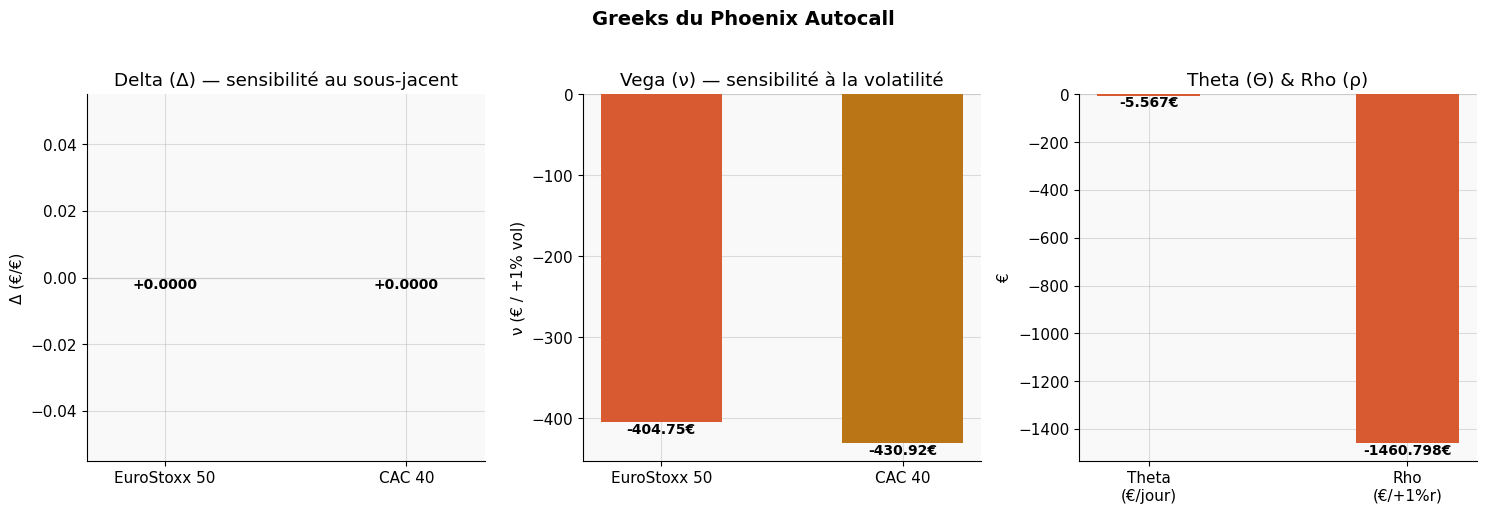

Graphique sauvegardé : greeks_bar.png


In [9]:
names = list(UNDERLYINGS.keys())

greeks_df = pd.DataFrame({
    "Sous-jacent": names,
    "Delta (Δ)":   [f"{d:+.4f}" for d in deltas],
    "Gamma (Γ)":   [f"{g:+.6f}" for g in gammas],
    "Vega (ν) €":  [f"{v:+.2f}" for v in vegas],
}).set_index("Sous-jacent")

greeks_df.loc["—"] = ["—", "—", "—"]
greeks_df.loc["Theta (Θ) €/j"] = ["—", "—", f"{theta:+.4f}"]
greeks_df.loc["Rho (ρ) €/%r"]  = ["—", "—", f"{rho:+.4f}"]

print(greeks_df.to_string())

# ─── Visualisation ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Greeks du Phoenix Autocall", fontsize=14, fontweight="bold", y=1.02)

# Delta
ax = axes[0]
bars = ax.bar(names, deltas, color=[PURPLE, TEAL], width=0.5, zorder=3)
ax.axhline(0, color="#ccc", lw=0.8)
ax.set_title("Delta (Δ) — sensibilité au sous-jacent")
ax.set_ylabel("Δ (€/€)")
for b, d in zip(bars, deltas):
    ax.text(b.get_x()+b.get_width()/2, d + 0.002*np.sign(d), f"{d:+.4f}",
            ha="center", va="bottom" if d>0 else "top", fontsize=10, fontweight="bold")

# Vega
ax = axes[1]
bars = ax.bar(names, vegas, color=[CORAL, AMBER], width=0.5, zorder=3)
ax.axhline(0, color="#ccc", lw=0.8)
ax.set_title("Vega (ν) — sensibilité à la volatilité")
ax.set_ylabel("ν (€ / +1% vol)")
for b, v in zip(bars, vegas):
    ax.text(b.get_x()+b.get_width()/2, v + 0.5*np.sign(v), f"{v:+.2f}€",
            ha="center", va="bottom" if v>0 else "top", fontsize=10, fontweight="bold")

# Theta & Rho
ax = axes[2]
labels = ["Theta\n(€/jour)", "Rho\n(€/+1%r)"]
values = [theta, rho]
colors = [PURPLE if v >= 0 else CORAL for v in values]
bars   = ax.bar(labels, values, color=colors, width=0.4, zorder=3)
ax.axhline(0, color="#ccc", lw=0.8)
ax.set_title("Theta (Θ) & Rho (ρ)")
ax.set_ylabel("€")
for b, val in zip(bars, values):
    ax.text(b.get_x()+b.get_width()/2, val + 0.1*np.sign(val), f"{val:+.3f}€",
            ha="center", va="bottom" if val>0 else "top", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("greeks_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : greeks_bar.png")


## 6. Surface de volatilité implicite

La surface de volatilité modélise la dépendance de $\sigma$ au **moneyness** ($K/S_0$) et à la **maturité** $T$.  
Elle est construite ici par une grille paramétrique (smile + term structure) puis interpolée par spline bivariée.


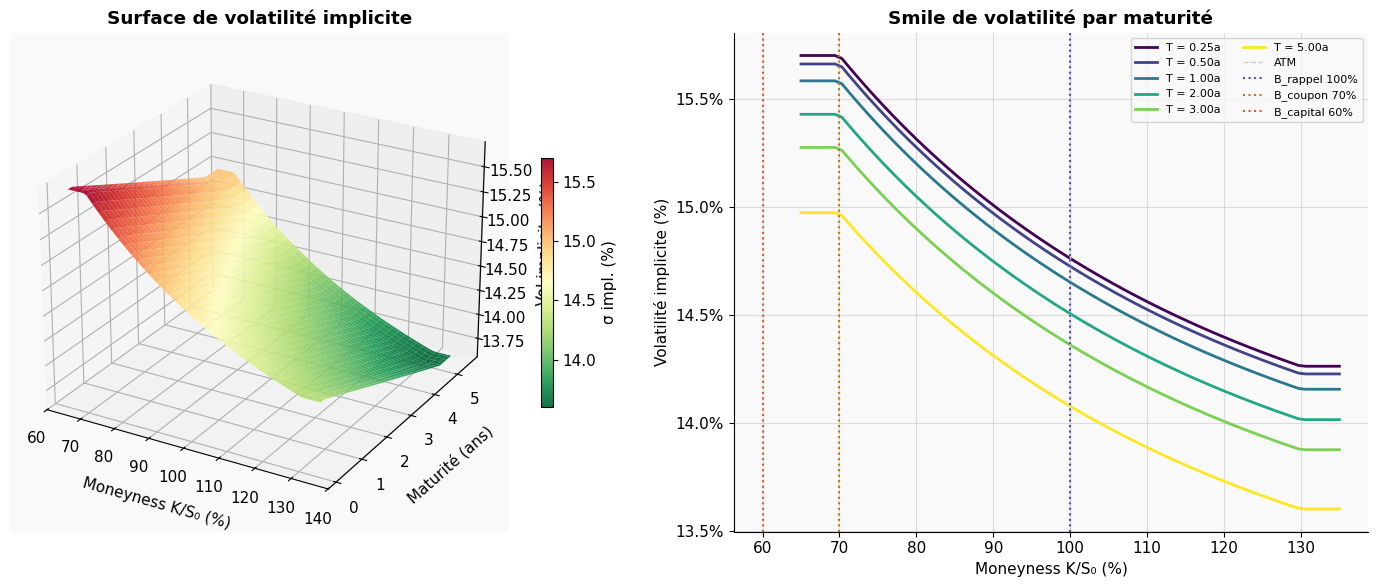

Surface de vol sauvegardée : vol_surface.png


In [10]:
# ─── Grille de volatilité (smile paramétrique) ────────────────────────────────
strikes_pct = np.array([0.70, 0.80, 0.90, 1.00, 1.10, 1.20, 1.30])
maturities  = np.array([0.25, 0.50, 1.0, 2.0, 3.0, 5.0])

# Smile : quadratique en log-moneyness + term structure
def vol_surface(K_pct, T_mat, atm_vol=0.148, skew=-0.15, kurt=0.08, term_slope=-0.01):
    log_m = np.log(K_pct)
    smile = atm_vol * (1 + skew * log_m + kurt * log_m**2)
    term  = smile * np.exp(term_slope * T_mat)
    return np.clip(term, 0.05, 0.60)

K_grid, T_grid = np.meshgrid(strikes_pct, maturities)
vol_grid = vol_surface(K_grid, T_grid)

# Interpolation spline bivariée
spline = RectBivariateSpline(maturities, strikes_pct, vol_grid, kx=3, ky=3)

# Grille fine pour le tracé
K_fine = np.linspace(0.65, 1.35, 80)
T_fine = np.linspace(0.1, 5.5, 80)
K_mesh, T_mesh = np.meshgrid(K_fine, T_fine)
vol_fine = spline(T_fine, K_fine)

# ─── Tracé 3D ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6))

# Surface 3D
ax1 = fig.add_subplot(121, projection="3d")
surf = ax1.plot_surface(K_mesh * 100, T_mesh, vol_fine * 100,
                        cmap="RdYlGn_r", alpha=0.92, edgecolor="none")
ax1.set_xlabel("Moneyness K/S₀ (%)", labelpad=8)
ax1.set_ylabel("Maturité (ans)", labelpad=8)
ax1.set_zlabel("Vol implicite (%)", labelpad=8)
ax1.set_title("Surface de volatilité implicite", fontweight="bold")
ax1.view_init(elev=25, azim=-60)
fig.colorbar(surf, ax=ax1, shrink=0.5, label="σ impl. (%)")

# Smiles par maturité
ax2 = fig.add_subplot(122)
colors_t = cm.viridis(np.linspace(0, 1, len(maturities)))
for i, (t_mat, col) in enumerate(zip(maturities, colors_t)):
    vols_smile = spline(t_mat, K_fine).flatten()
    ax2.plot(K_fine * 100, vols_smile * 100, color=col, lw=2,
             label=f"T = {t_mat:.2f}a")

ax2.axvline(100, color="#ccc", lw=1, ls="--", label="ATM")
ax2.axvline(B_RECALL*100,  color=PURPLE, lw=1.5, ls=":", label=f"B_rappel {B_RECALL*100:.0f}%")
ax2.axvline(B_COUPON*100,  color=AMBER,  lw=1.5, ls=":", label=f"B_coupon {B_COUPON*100:.0f}%")
ax2.axvline(B_CAPITAL*100, color=CORAL,  lw=1.5, ls=":", label=f"B_capital {B_CAPITAL*100:.0f}%")

ax2.set_xlabel("Moneyness K/S₀ (%)")
ax2.set_ylabel("Volatilité implicite (%)")
ax2.set_title("Smile de volatilité par maturité", fontweight="bold")
ax2.legend(fontsize=8, ncol=2)
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f%%"))

plt.tight_layout()
plt.savefig("vol_surface.png", dpi=150, bbox_inches="tight")
plt.show()
print("Surface de vol sauvegardée : vol_surface.png")


## 7. Distribution des payoffs & profil risque/rendement

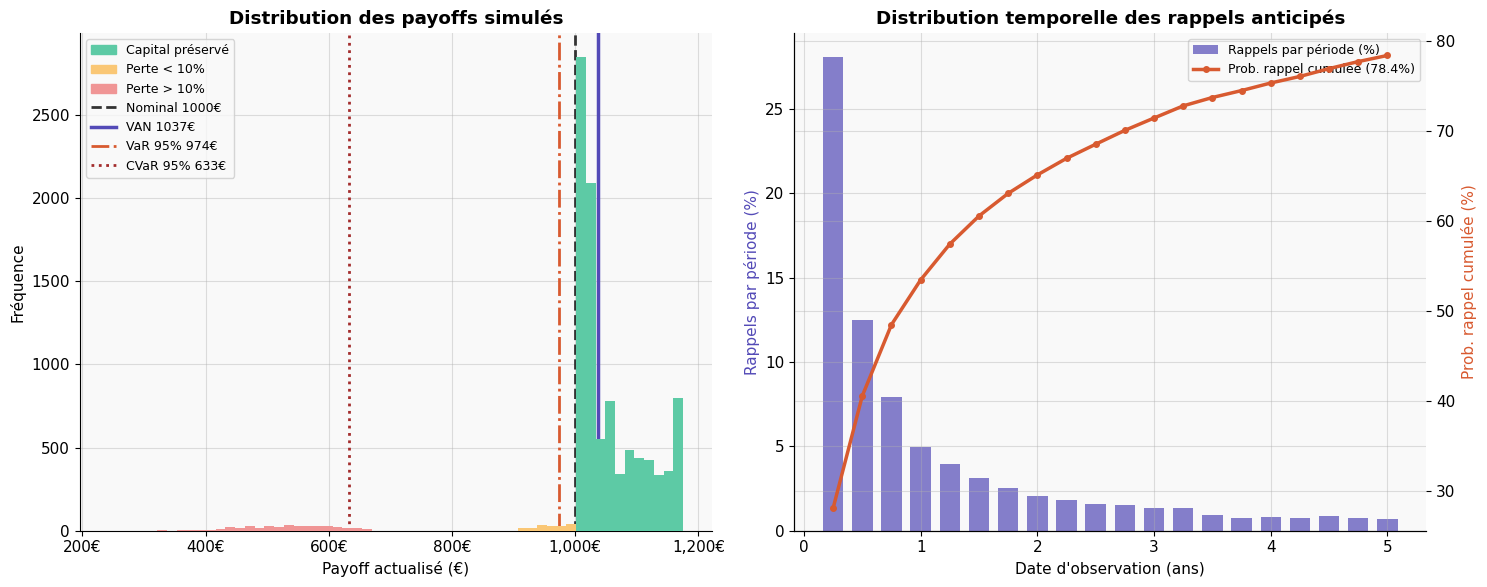

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ─── Histogramme ─────────────────────────────────────────────────────────────
ax = axes[0]
bins = np.linspace(payoffs_base.min(), payoffs_base.max(), 60)

# Call hist without the color argument, then iterate through patches to set colors
n, bins, patches = ax.hist(payoffs_base, bins=bins, edgecolor="none", zorder=3)

for patch, bin_start, bin_end in zip(patches, bins[:-1], bins[1:]):
    mid = (bin_start + bin_end) / 2
    if mid < NOMINAL * 0.9:
        patch.set_facecolor("#F09595") # Red for loss > 10%
    elif mid < NOMINAL:
        patch.set_facecolor("#FAC775") # Orange for loss < 10%
    else:
        patch.set_facecolor("#5DCAA5") # Green for capital preserved

ax.axvline(NOMINAL,        color="#333",  lw=2,   ls="--",  label=f"Nominal {NOMINAL}€")
ax.axvline(price_base,     color=PURPLE,  lw=2.5, ls="-",   label=f"VAN {price_base:.0f}€")
ax.axvline(var95,          color=CORAL,   lw=2,   ls="-.",   label=f"VaR 95% {var95:.0f}€")
ax.axvline(cvar95,         color="#A32D2D", lw=2, ls=":",    label=f"CVaR 95% {cvar95:.0f}€")

from matplotlib.patches import Patch
legend_els = [
    Patch(color="#5DCAA5", label="Capital préservé"),
    Patch(color="#FAC775", label="Perte < 10%"),
    Patch(color="#F09595", label="Perte > 10%"),
]
ax.legend(handles=legend_els + ax.get_legend_handles_labels()[0][:4],
          fontsize=9, loc="upper left")
ax.set_xlabel("Payoff actualisé (€)")
ax.set_ylabel("Fréquence")
ax.set_title("Distribution des payoffs simulés", fontweight="bold")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}€"))

# ─── Distribution des dates de rappel ────────────────────────────────────────
ax2 = axes[1]
if call_times_base:
    call_arr = np.array(call_times_base)
    obs_times = np.arange(dt, T + dt, dt)
    counts = [np.sum(np.abs(call_arr - t) < 1e-9) for t in obs_times]
    cumul  = np.cumsum(counts) / N_SIMS * 100

    ax2b = ax2.twinx()
    ax2.bar(obs_times, [c/N_SIMS*100 for c in counts], width=dt*0.7,
            color=PURPLE, alpha=0.7, label="Rappels par période (%)")
    ax2b.plot(obs_times, cumul, color=CORAL, lw=2.5, marker="o", ms=4,
              label=f"Prob. rappel cumulée ({pct_called:.1f}%)")

    ax2.set_xlabel("Date d'observation (ans)")
    ax2.set_ylabel("Rappels par période (%)", color=PURPLE)
    ax2b.set_ylabel("Prob. rappel cumulée (%)", color=CORAL)
    ax2.set_title("Distribution temporelle des rappels anticipés", fontweight="bold")

    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2b.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
else:
    ax2.text(0.5, 0.5, "Aucun rappel anticipé simulé",
             transform=ax2.transAxes, ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.savefig("payoff_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Analyse de sensibilité — Greeks vs paramètres

Calcul des courbes de sensibilité (~2 min)...


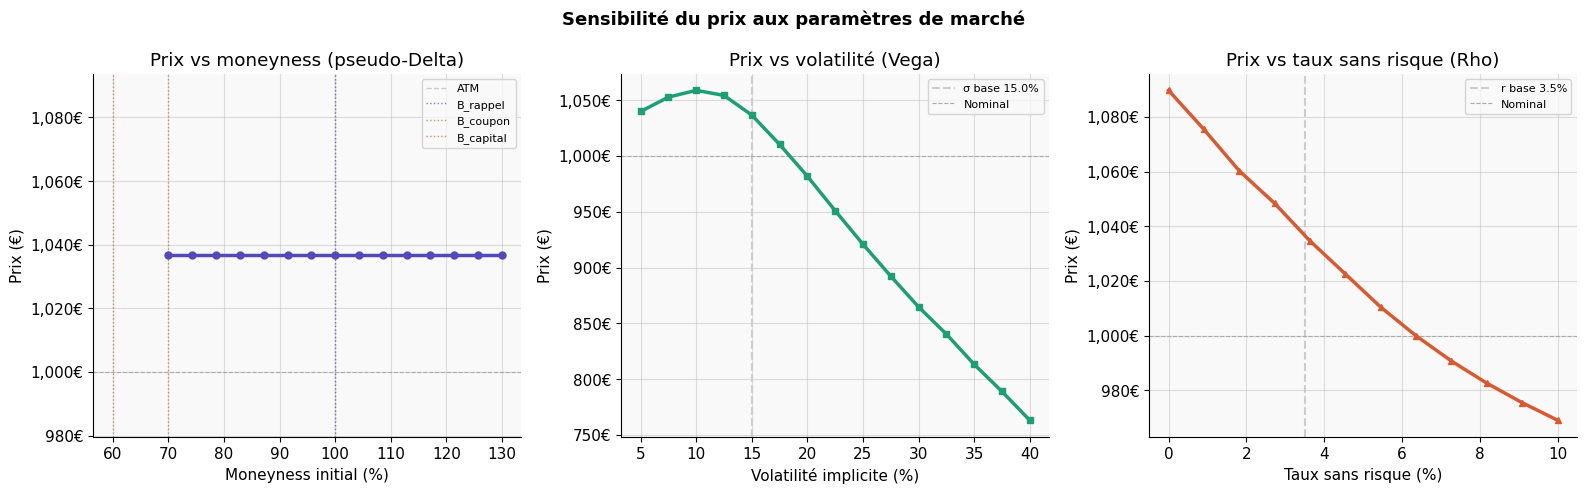

Analyse de sensibilité sauvegardée ✓


In [14]:
print("Calcul des courbes de sensibilité (~2 min)...")

# ─── Delta vs moneyness ───────────────────────────────────────────────────────
moneyness_range = np.linspace(0.70, 1.30, 15)
deltas_mono = []
for m in moneyness_range:
    S_list = [s * m for s in S0_arr]
    dp, _, _, _ = simulate_phoenix(
        S_list, vols, 2000, N_STEPS, dt, r,
        B_RECALL, B_COUPON, B_CAPITAL,
        COUPON_RATE, FREQ, T, NOMINAL,
        BASKET_METHOD, MEMORY_EFFECT, seed=42
    )
    deltas_mono.append(dp)

# ─── Vega vs niveau de vol ────────────────────────────────────────────────────
vol_range = np.linspace(0.05, 0.40, 15)
prices_vol = []
for vol_level in vol_range:
    vols_test = [vol_level] * len(S0_arr)
    dp, _, _, _ = simulate_phoenix(
        list(S0_arr), vols_test, 2000, N_STEPS, dt, r,
        B_RECALL, B_COUPON, B_CAPITAL,
        COUPON_RATE, FREQ, T, NOMINAL,
        BASKET_METHOD, MEMORY_EFFECT, seed=42
    )
    prices_vol.append(dp)

# ─── Prix vs taux sans risque ────────────────────────────────────────────────
r_range = np.linspace(0.00, 0.10, 12)
prices_r = []
for ri in r_range:
    dp, _, _, _ = simulate_phoenix(
        list(S0_arr), vols, 2000, N_STEPS, dt, ri,
        B_RECALL, B_COUPON, B_CAPITAL,
        COUPON_RATE, FREQ, T, NOMINAL,
        BASKET_METHOD, MEMORY_EFFECT, seed=42
    )
    prices_r.append(dp)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Sensibilité du prix aux paramètres de marché", fontsize=13, fontweight="bold")

# Delta vs moneyness
ax = axes[0]
ax.plot(moneyness_range * 100, deltas_mono, color=PURPLE, lw=2.5, marker="o", ms=5, zorder=3)
ax.axvline(100, color="#ccc", lw=1, ls="--", label="ATM")
ax.axvline(B_RECALL*100,  color=PURPLE, lw=1, ls=":", alpha=0.7, label=f"B_rappel")
ax.axvline(B_COUPON*100,  color=AMBER,  lw=1, ls=":", alpha=0.7, label=f"B_coupon")
ax.axvline(B_CAPITAL*100, color=CORAL,  lw=1, ls=":", alpha=0.7, label=f"B_capital")
ax.axhline(NOMINAL, color="#aaa", lw=0.8, ls="--")
ax.set_xlabel("Moneyness initial (%)")
ax.set_ylabel("Prix (€)")
ax.set_title("Prix vs moneyness (pseudo-Delta)")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x:,.0f}€"))

# Prix vs volatilité (Vega)
ax = axes[1]
ax.plot(vol_range * 100, prices_vol, color=TEAL, lw=2.5, marker="s", ms=5, zorder=3)
ax.axvline(np.mean(vols)*100, color="#ccc", lw=1.5, ls="--", label=f"σ base {np.mean(vols)*100:.1f}%")
ax.axhline(NOMINAL, color="#aaa", lw=0.8, ls="--", label="Nominal")
ax.set_xlabel("Volatilité implicite (%)")
ax.set_ylabel("Prix (€)")
ax.set_title("Prix vs volatilité (Vega)")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x:,.0f}€"))

# Prix vs taux (Rho)
ax = axes[2]
ax.plot(r_range * 100, prices_r, color=CORAL, lw=2.5, marker="^", ms=5, zorder=3)
ax.axvline(r*100, color="#ccc", lw=1.5, ls="--", label=f"r base {r*100:.1f}%")
ax.axhline(NOMINAL, color="#aaa", lw=0.8, ls="--", label="Nominal")
ax.set_xlabel("Taux sans risque (%)")
ax.set_ylabel("Prix (€)")
ax.set_title("Prix vs taux sans risque (Rho)")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x:,.0f}€"))

plt.tight_layout()
plt.savefig("sensitivity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Analyse de sensibilité sauvegardée ✓")


## 9. Récapitulatif exécutif

In [15]:
print("=" * 55)
print("   RÉCAPITULATIF — PHOENIX AUTOCALL")
print("=" * 55)
print(f"  Sous-jacents   : {', '.join(UNDERLYINGS.keys())}")
print(f"  Méthode panier : {BASKET_METHOD}-of")
print(f"  Maturité       : {T} ans ({N_STEPS} observations)")
print(f"  Nominal        : {NOMINAL:,.0f} €")
print()
print(f"  ── PRIX & RENDEMENT ──────────────────────────")
print(f"  VAN espérée        : {price_base:>10.2f} €")
print(f"  Rendement espéré   : {(price_base/NOMINAL-1)*100:>+9.2f} %")
print()
print(f"  ── INDICATEURS DE RISQUE ─────────────────────")
print(f"  VaR 95%            : {var95:>10.2f} €")
print(f"  CVaR 95%           : {cvar95:>10.2f} €")
print(f"  Prob. capital préservé : {pct_capital:>6.1f} %")
print(f"  Prob. perte > 10%      : {pct_loss10:>6.1f} %")
print()
print(f"  ── RAPPEL ANTICIPÉ ───────────────────────────")
print(f"  Prob. rappel       : {pct_called:>10.1f} %")
if avg_call:
    print(f"  Durée moy. rappel  : {avg_call:>9.2f} ans")
print()
print(f"  ── GREEKS ────────────────────────────────────")
for name, d, g, v in zip(names, deltas, gammas, vegas):
    print(f"  {name[:20]:20s}  Δ={d:+.4f}  Γ={g:+.6f}  ν={v:+.2f}€")
print(f"  {'Theta':20s}  Θ={theta:+.4f} €/jour")
print(f"  {'Rho':20s}  ρ={rho:+.4f} €/1%r")
print("=" * 55)


   RÉCAPITULATIF — PHOENIX AUTOCALL
  Sous-jacents   : EuroStoxx 50, CAC 40
  Méthode panier : worst-of
  Maturité       : 5.0 ans (20 observations)
  Nominal        : 1,000 €

  ── PRIX & RENDEMENT ──────────────────────────
  VAN espérée        :    1037.20 €
  Rendement espéré   :     +3.72 %

  ── INDICATEURS DE RISQUE ─────────────────────
  VaR 95%            :     973.77 €
  CVaR 95%           :     632.68 €
  Prob. capital préservé :   94.5 %
  Prob. perte > 10%      :    3.8 %

  ── RAPPEL ANTICIPÉ ───────────────────────────
  Prob. rappel       :       78.4 %
  Durée moy. rappel  :      1.11 ans

  ── GREEKS ────────────────────────────────────
  EuroStoxx 50          Δ=+0.0000  Γ=+0.000000  ν=-404.75€
  CAC 40                Δ=+0.0000  Γ=+0.000000  ν=-430.92€
  Theta                 Θ=-5.5672 €/jour
  Rho                   ρ=-1460.7981 €/1%r
